In [31]:
# Prepare the Data for Machine Learning Algorithms
import pandas as pd
import numpy as np
from utils import load_housing_data
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

housing = load_housing_data()
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5],
)

strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

# Revert to a clean training set
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB
None


### Clean the Data (total_bedrooms attribute has some missing values.)
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the missing values to some value (zero, the mean, the median, etc.). This is
called imputation.

In [24]:
housing.dropna(subset=["total_bedrooms"], inplace=True) # option 1
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16344 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16344 non-null  float64 
 1   latitude            16344 non-null  float64 
 2   housing_median_age  16344 non-null  float64 
 3   total_rooms         16344 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16344 non-null  float64 
 6   households          16344 non-null  float64 
 7   median_income       16344 non-null  float64 
 8   ocean_proximity     16344 non-null  object  
 9   income_cat          16344 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB
None


In [20]:
housing.drop("total_bedrooms", axis=1, inplace=True) # option 2
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   population          16512 non-null  float64 
 5   households          16512 non-null  float64 
 6   median_income       16512 non-null  float64 
 7   ocean_proximity     16512 non-null  object  
 8   income_cat          16512 non-null  category
dtypes: category(1), float64(7), object(1)
memory usage: 1.1+ MB
None


In [25]:
median = housing["total_bedrooms"].median() # option 3
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16344 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16344 non-null  float64 
 1   latitude            16344 non-null  float64 
 2   housing_median_age  16344 non-null  float64 
 3   total_rooms         16344 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16344 non-null  float64 
 6   households          16344 non-null  float64 
 7   median_income       16344 non-null  float64 
 8   ocean_proximity     16344 non-null  object  
 9   income_cat          16344 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB
None


### Clean the Data (imputation.) with Sklearn

In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
# Copy a data only the numerical atts, exclude ocean_proximity
housing_num = housing.select_dtypes(include=[np.number])
# Calculates the median for each column in housing_num
imputer.fit(housing_num)
# Check calculated medians
print(housing_num.median().values)
# transform replaces gaps with calculated medians
X = imputer.transform(housing_num)

# recover the column names and index from housing_num
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
print(housing_tr.info())


[-118.51     34.26     29.     2125.5     434.     1167.      408.5
    3.5409]
<class 'pandas.core.frame.DataFrame'>
Index: 16344 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16344 non-null  float64
 1   latitude            16344 non-null  float64
 2   housing_median_age  16344 non-null  float64
 3   total_rooms         16344 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16344 non-null  float64
 6   households          16344 non-null  float64
 7   median_income       16344 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB
None


In [11]:
# Format text data to numerical data

# Read original data
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print(housing_cat_encoded[:8])
print(housing_cat[:8])
print(ordinal_encoder.categories_)

# '<1H OCEAN' < 'INLAND' < 'ISLAND' < 'NEAR BAY' < 'NEAR OCEAN'
# 0 < 1 < 2 < 3 < 4
# NEAR OCEAN (4) >  INLAND (1) !!!
# "NEAR THE OCEAN is 4 times farther from <1H OCEAN than INLAND"
# problem can be in linear regression 
# price = w * ocean_proximity
# The higher the number, the higher the price. 
# NEAR OCEAN (4) is always "better" than INLAND (1).



[[3.]
 [0.]
 [1.]
 [1.]
 [4.]
 [1.]
 [0.]
 [3.]]
      ocean_proximity
13096        NEAR BAY
14973       <1H OCEAN
3785           INLAND
14689          INLAND
20507      NEAR OCEAN
1286           INLAND
18078       <1H OCEAN
4396         NEAR BAY
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [12]:
# Can solve promblem with OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
# Categories are equal,  There is no automatic “better/worse”
print(housing_cat_1hot[:8].toarray())
# price = w1*INLAND + w2*NEAR_BAY + w3*ISLAND + ...
print("Sparse format: (row, column) -> value\n", housing_cat_1hot[:8])
# list of cats encoder
cat_encoder.categories_

[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]
Sparse format: (row, column) -> value
   (0, 3)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 4)	1.0
  (5, 1)	1.0
  (6, 0)	1.0
  (7, 3)	1.0


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
# Pandas function to convert categorical feature into one-hot representation
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

# Using trained OneHotEncoder (fit on train data before)
result = cat_encoder.transform(df_test)
print("trained OneHotEncoder\n")
print(result[:8].toarray())

# Do NOT use pd.get_dummies() in ML pipelines:
# - It creates columns based only on current data
# - Train and test may have different categories → different columns
# - This leads to feature mismatch and breaks the model

# OneHotEncoder:
# - Learns categories during fit() on training data
# - Always outputs the same number and order of features
# - Ensures consistency between train and test data


# Example with unknown category
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
print("example with unknown category\n")
print(pd.get_dummies(df_test_unknown))

# ⚠️ OneHotEncoder will raise an error for unseen categories by default
# This is GOOD: it prevents silent bugs and unexpected behavior

# Optional (use carefully):
#cat_encoder.handle_unknown = "ignore"
# print(cat_encoder.transform(df_test_unknown)[:8].toarray())
# → unknown category will be encoded as [0, 0, ..., 0]

# ⚠️ Warning:
# Ignoring unknown categories may hide data issues
# Use only if you understand the implications

In [ ]:
# Avoiding column mistmatches and useful when debugging
print(cat_encoder.feature_names_in_)

print(cat_encoder.get_feature_names_out())

# Found unknown categories ['<2H OCEAN'] in column 0 during transform
df_output = pd.DataFrame(
    cat_encoder.transform(df_test_unknown),
    columns=cat_encoder.get_feature_names_out(),
    index=df_test_unknown.index,
)

### Feature Scaling and Transformation

In [ ]:
# Min-max scaling (normalization))
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
print("original data - \n", housing_num[:3].to_numpy(), "\n")
print("housing_num_min_max_scaled\n", housing_num_min_max_scaled[:3])

In [6]:
# Standardization
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

print("original data - \n", housing_num[:3].to_numpy(), "\n")
print("housing_num_std_scaled\n", housing_num_std_scaled[:3])


original data - 
 [[-1.2242e+02  3.7800e+01  5.2000e+01  3.3210e+03  1.1150e+03  1.5760e+03
   1.0340e+03  2.0987e+00]
 [-1.1838e+02  3.4140e+01  4.0000e+01  1.9650e+03  3.5400e+02  6.6600e+02
   3.5700e+02  6.0876e+00]
 [-1.2198e+02  3.8360e+01  3.3000e+01  1.0830e+03  2.1700e+02  5.6200e+02
   2.0300e+02  2.4330e+00]] 

housing_num_std_scaled
 [[-1.42303652  1.0136059   1.86111875  0.31191221  1.35909429  0.13746004
   1.39481249 -0.93649149]
 [ 0.59639445 -0.702103    0.90762971 -0.30861991 -0.43635598 -0.69377062
  -0.37348471  1.17194198]
 [-1.2030985   1.27611874  0.35142777 -0.71224036 -0.75958421 -0.78876841
  -0.77572662 -0.75978881]]


In [48]:
# Min-Max Scaling (manual)
import numpy as np

# Raw feature (very different scale example)
x = np.array([10, 20, 30, 40, 50], dtype=float)

# --- Min-Max Scaling ---
# Formula:
# x_scaled = (x - x_min) / (x_max - x_min)

x_min = x.min()
x_max = x.max()

x_minmax_01 = (x - x_min) / (x_max - x_min)

print("Original:", x)
print("Min:", x_min, "Max:", x_max)
print("MinMax [0,1]:", x_minmax_01)

# General formula with custom range [a, b]:
# x_scaled = a + (x - x_min) * (b - a) / (x_max - x_min)
a, b = -1, 1
x_minmax_m11 = a + (x - x_min) * (b - a) / (x_max - x_min)

print("MinMax [-1,1]:", x_minmax_m11)


Original: [10. 20. 30. 40. 50.]
Min: 10.0 Max: 50.0
MinMax [0,1]: [0.   0.25 0.5  0.75 1.  ]
MinMax [-1,1]: [-1.  -0.5  0.   0.5  1. ]


In [ ]:
# --- Standardization --- (manual)
# Formula:
# x_scaled = (x - mean) / std

mean = x.mean()
std = x.std()  # population std (same idea as sklearn default)
# mean = (10 + 20 + 30 + 40 + 50) / 5 = 30
# 10 - 30 => -20; 20 - 30 => -10; 30 - 30 => 0; 40 - 30 = 10; 50 - 30 = 20;
# in square -> 400; 100; 0; 100; 400
# sum it, (400 + 100 + 0 + 100 + 400) / 5 = 200
# std = square 200 = 14.14 (число из корня при умножение на себя дает его же)

x_standardized = (x - mean) / std

print("Mean:", mean, "Std:", std)
print("Standardized:", x_standardized)

std (standard deviation)

μ (mu) — (mean)

$$\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$$

In [10]:
# Пример с выбросом (Data with an outlier)
# Data with an outlier
x_outlier = np.array([10, 20, 30, 40, 50, 300], dtype=float)

# MinMax
x_min = x_outlier.min()
x_max = x_outlier.max()
x_minmax = (x_outlier - x_min) / (x_max - x_min)

# Standardization
mean = x_outlier.mean()
std = x_outlier.std()
x_std = (x_outlier - mean) / std

print("\n--- With Outlier ---")
print("Original:", x_outlier)
print("MinMax:", x_minmax)
print("Standardized:", x_std)


--- With Outlier ---
Original: [ 10.  20.  30.  40.  50. 300.]
MinMax: [0.         0.03448276 0.06896552 0.10344828 0.13793103 1.        ]
Standardized: [-0.64072328 -0.54215046 -0.44357765 -0.34500484 -0.24643203  2.21788826]


In [40]:
# RBF shows how similar x is to 35.
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)



In [22]:
# Transform target prices, train model, then revert predictions to original scale
# Single input feature: median income

from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5] # pretend this is new data
scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)
print("predicted prices\n", predictions)

predicted prices
 [[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]]


In [24]:
# Auto rescaling 
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(LinearRegression(),
transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)
print("predicted prices\n", predictions)

predicted prices
 [131997.15275877 299359.35844434 146023.37185694 138840.33653057
 192016.61557639]


In [ ]:
# Custom Transformers
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])
print("original\n", housing[["population"]][:5])
print("after log transformer\n",log_pop[:5])

# inverse_func be good if plan use it in TransformedTargetRegressor
# for making like rescaling 

original
        population
13096      1576.0
14973       666.0
3785        562.0
14689      1845.0
20507      1912.0
after log transformer
        population
13096    7.362645
14973    6.501290
3785     6.331502
14689    7.520235
20507    7.555905


In [30]:
# Gaussian RBF similarity with median age and 35 example
from sklearn.metrics.pairwise import rbf_kernel
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.0]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])
print(age_simil_35[:5])

[[2.81118530e-13]
 [8.20849986e-02]
 [6.70320046e-01]
 [8.48904403e-15]
 [9.04837418e-01]]


In [31]:
# Add a feature for measure the geographic similarity between each district and San Francisco

sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])
print(sf_simil[:5])

[[0.999927  ]
 [0.05258419]
 [0.94864161]
 [0.01192662]
 [0.03275557]]


$$K(x, c) = e^{-\gamma \|x - c\|^2}$$

* `x` — координаты точки (например, города: latitude, longitude)
* `c` — центр (опорная точка, например Токио)
* `x - c` — разница координат (вектор от центра к точке)
* `‖x - c‖` — евклидово расстояние между точками
* `‖x - c‖^2` — квадрат расстояния (сумма квадратов разностей по каждой оси)
* `γ (gamma)` — параметр, управляющий скоростью убывания (чем больше, тем быстрее сходство падает)
* `e` — математическая константа (~2.718), основа экспоненты
* `e^x` — экспоненциальная функция (`exp(x)`), быстро растёт или убывает

---

In [46]:

import numpy as np

### Example: compute RBF similarity between Yokohama and Tokyo

#### Center point (Tokyo)
c_lat, c_lon = 35.6895, 139.6917

####  Target point (Yokohama)
x_lat, x_lon = 35.4437, 139.6380

####  Step 1. Difference (x - c)
lat_diff = x_lat - c_lat      # difference in latitude
lon_diff = x_lon - c_lon      # difference in longitude

####  Step 2. Square differences ((x - c)^2 for each dimension)
lat_diff_sq = lat_diff ** 2
lon_diff_sq = lon_diff ** 2

####  Step 3. Sum of squares (||x - c||^2) -> squared Euclidean distance
distance_sq = lat_diff_sq + lon_diff_sq

####  Step 4. Multiply by gamma (γ * ||x - c||^2)
gamma = 0.1
scaled_distance = gamma * distance_sq

####  Step 5. Add negative sign (-γ * ||x - c||^2)
negative_scaled_distance = -scaled_distance
####  Step 6. Apply exponential (exp(-γ * ||x - c||^2))
similarity = np.exp(negative_scaled_distance)

print(f"RBF similarity to Tokyo: {similarity:.4f}")

RBF similarity to Tokyo: 0.9937


In [43]:
# Compute geographic similarity to Tokyo using Gaussian RBF (kernel).
# Converts (latitude, longitude) into a similarity score in [0, 1]:
# 1 = same location, values → 0 as distance increases.
import pandas as pd

# Another example for geographic similarity
jp_cords = 35.6895, 139.6917  # 東京

jp_set_cords = pd.DataFrame(
    {
        "city": [
            "Tokyo",
            "Shibuya",
            "Yokohama",
            "Kyoto",
            "Osaka",
            "Sapporo",
            "Okinawa",
        ],
        "latitude": [
            35.6895,
            35.6762,
            35.4437,
            35.0116,
            34.6937,
            43.0621,
            26.2124,
        ],
        "longitude": [
            139.6917,
            139.6503,
            139.6380,
            135.7681,
            135.5023,
            141.3545,
            127.6809,
        ],
    }
)
jp_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[jp_cords], gamma=0.1))
jp_simil = jp_transformer.transform(jp_set_cords[["latitude", "longitude"]])
jp_set_cords["tokyo_similarity"] = jp_simil
jp_set_cords["tokyo_similarity"] = jp_set_cords["tokyo_similarity"].round(3)

print(jp_set_cords)

       city  latitude  longitude  tokyo_similarity
0     Tokyo   35.6895   139.6917             1.000
1   Shibuya   35.6762   139.6503             1.000
2  Yokohama   35.4437   139.6380             0.994
3     Kyoto   35.0116   135.7681             0.205
4     Osaka   34.6937   135.5023             0.157
5   Sapporo   43.0621   141.3545             0.003
6   Okinawa   26.2124   127.6809             0.000


/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[[0.08 0.   0.6  0.   0.   0.99 0.   0.   0.   0.14]
 [0.   0.99 0.   0.04 0.   0.   0.11 0.   0.63 0.  ]
 [0.44 0.   0.3  0.   0.   0.7  0.   0.01 0.   0.29]]


<Axes: xlabel='longitude', ylabel='latitude'>

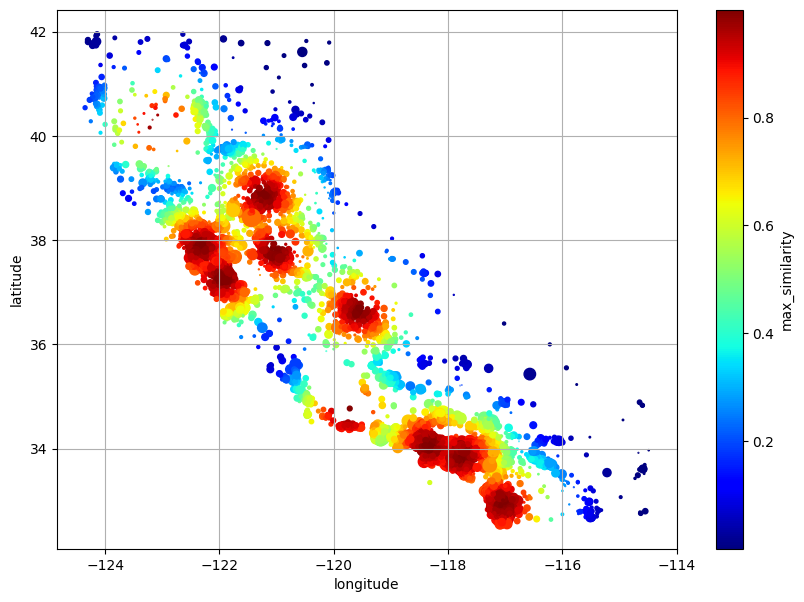

In [42]:
# Find a center of the 10 most expensive regions in California
# And to measure the distance from each district of these centers
# Adding 10 corresponding RBF similiarity features

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans


class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean = X.mean(axis=0)
        self.scale = X.std(
            axis=0
        )  # 0 by rows → count columns, 1 to the right (by columns → counting rows)
        self.n_features_in = X.shape[1]  # every estimator store this in fit()
        # shape is bellow
        # X = np.array([
        #  [1, 2],
        #  [3, 4],
        #   [5, 6]
        # ])
        # print(X.shape)
        # return as (rows, columns) (3, 2)
        return self  # alwas return self!

    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        assert self.n_features_in == X.shape[1]
        if self.with_mean:
            X = X - self.mean
        return X / self.scale_


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        # number of geographic clusters (regions)
        self.n_clusters = n_clusters
        
        # controls how fast similarity decreases with distance
        self.gamma = gamma
        
        # for reproducibility
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # Step 1: find cluster centers using KMeans
        # X = [latitude, longitude]
        
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )
        
        # sample_weight makes expensive districts more important
        self.kmeans_.fit(X, sample_weight=sample_weight)
        
        return self

    def transform(self, X):
        # Step 2: compute similarity to each cluster center
        
        # output shape: (n_samples, n_clusters)
        return rbf_kernel(
            X,
            self.kmeans_.cluster_centers_,
            gamma=self.gamma
        )

    def get_feature_names_out(self, names=None):
        return [
            f"Cluster {i} similarity"
            for i in range(self.n_clusters)
        ]
# 10 clusters ? groups , how is similar , find centers
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]],
sample_weight=housing_labels)
print(similarities[:3].round(2))

similarities_df = pd.DataFrame(
    similarities,
    columns=[f"cluster_{i}" for i in range(similarities.shape[1])]
)
similarities_df["latitude"] = housing["latitude"].values
similarities_df["longitude"] = housing["longitude"].values
similarities_df["max_similarity"] = similarities_df[
    [f"cluster_{i}" for i in range(similarities.shape[1])]
].max(axis=1)
similarities_df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=housing["population"] / 100,
    c="max_similarity",
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
)

   cluster_0  cluster_1  cluster_2  latitude  longitude      city  \
0        0.0       0.15        0.0     35.69     139.69     Tokyo   
1        0.0       0.16        0.0     35.68     139.65   Shibuya   
2        0.0       0.19        0.0     35.44     139.64  Yokohama   
3        0.0       0.00        0.0     35.01     135.77     Kyoto   
4        0.0       0.00        0.0     34.69     135.50     Osaka   
5        1.0       0.00        0.0     43.06     141.35   Sapporo   
6        0.0       0.00        1.0     26.21     127.68   Okinawa   

   max_similarity  
0            0.15  
1            0.16  
2            0.19  
3            0.00  
4            0.00  
5            1.00  
6            1.00  


/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


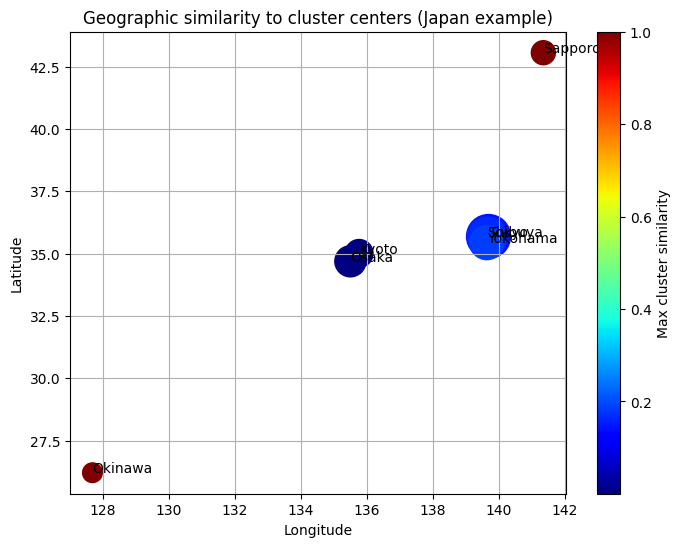

In [59]:
# Example on raw data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Mock dataset (Japan cities)
# ----------------------------

data = pd.DataFrame({
    "city": [
        "Tokyo", "Shibuya", "Yokohama",
        "Kyoto", "Osaka", "Sapporo", "Okinawa"
    ],
    "latitude": [
        35.6895, 35.6762, 35.4437,
        35.0116, 34.6937, 43.0621, 26.2124
    ],
    "longitude": [
        139.6917, 139.6503, 139.6380,
        135.7681, 135.5023, 141.3545, 127.6809
    ],
    # fake housing prices (higher in big cities)
    "price": [
        1000, 1200, 900,
        700, 800, 500, 300
    ],
    "population": [
        10000, 8000, 6000,
        4000, 5000, 3000, 2000
    ]
})

# ----------------------------
# Features and labels
# ----------------------------

X = data[["latitude", "longitude"]]   # geographic features
y = data["price"]                    # used as sample_weight

# ----------------------------
# Apply ClusterSimilarity
# ----------------------------

cluster_simil = ClusterSimilarity(
    n_clusters=3,        # small number so it's easy to understand
    gamma=1.0,
    random_state=42
)

# fit: find clusters (biased toward high price areas)
# transform: compute similarity to each cluster
similarities = cluster_simil.fit_transform(X, sample_weight=y)

# ----------------------------
# Convert to DataFrame
# ----------------------------

similarities_df = pd.DataFrame(
    similarities,
    columns=[f"cluster_{i}" for i in range(similarities.shape[1])]
)

# add original data back
similarities_df["latitude"] = data["latitude"]
similarities_df["longitude"] = data["longitude"]
similarities_df["city"] = data["city"]

# max similarity = closest cluster
similarities_df["max_similarity"] = similarities_df[
    [f"cluster_{i}" for i in range(similarities.shape[1])]
].max(axis=1)

print(similarities_df.round(2))

# ----------------------------
# Plot
# ----------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    similarities_df["longitude"],
    similarities_df["latitude"],
    
    # size ~ population
    s=data["population"] / 10,
    
    # color = similarity to nearest cluster
    c=similarities_df["max_similarity"],
    
    cmap="jet"
)

# annotate cities
for i, row in similarities_df.iterrows():
    plt.text(row["longitude"], row["latitude"], row["city"])

plt.colorbar(label="Max cluster similarity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic similarity to cluster centers (Japan example)")
plt.grid(True)

plt.show()

In [ ]:
# Transformation Pipelines
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# SimpleImputer - fill null data
num_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("standardize", StandardScaler()),
    ]
)

# Auto naming
# num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

housing_num_prepared = num_pipeline.fit_transform(housing_num)
print(housing_num_prepared[:2].round(2))

# Recover DataFrame
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared,
    columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index,
)

[[-1.42  1.01  1.86  0.31  1.37  0.14  1.39 -0.94]
 [ 0.6  -0.7   0.91 -0.31 -0.44 -0.69 -0.37  1.17]]


In [36]:
# Single transformer capable handling all columns (instead separete numerical and categorical)
# Apply to exist pipeline
from sklearn.compose import ColumnTransformer

num_attribs = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]
cat_attribs = ["ocean_proximity"]
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")
)
preprocessing = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs), # use exist pipeline
        ("cat", cat_pipeline, cat_attribs), # use a new pipeline
    ]
)
column_prepared = preprocessing.fit_transform(housing)
print(column_prepared[:2].round(2))

[[-1.42  1.01  1.86  0.31  1.37  0.14  1.39 -0.94  0.    0.    0.    1.
   0.  ]
 [ 0.6  -0.7   0.91 -0.31 -0.44 -0.69 -0.37  1.17  1.    0.    0.    0.
   0.  ]]


In [43]:
# Build a unified preprocessing pipeline that applies all previously explored transformations:
# - Impute missing values (median for numerical features, most frequent for categorical ones)
# - Encode categorical features using One-Hot Encoding (models require numerical input)
# - Generate additional ratio features (e.g., bedrooms_ratio, rooms_per_house, people_per_house)
#   to better capture relationships with the target variable
# - Add cluster-based similarity features derived from geographical coordinates
# - Apply log transformation to skewed (long-tail) features to normalize their distribution
# - Standardize numerical features so that all features are on a similar scale
#
# ColumnTransformer orchestrates these steps by applying specific pipelines to selected columns
# and combining the results into a single feature matrix ready for model training.
from sklearn.compose import make_column_selector
from sklearn.preprocessing import FunctionTransformer


def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out


def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler(),
    )


log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler(),
)
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
preprocessing = ColumnTransformer(
    [
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        (
            "log",
            log_pipeline,
            [
                "total_bedrooms",
                "total_rooms",
                "population",
                "households",
                "median_income",
            ],
        ),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline,
)  # one column remaining: housing_median_age

housing_prepared = preprocessing.fit_transform(housing)
print(housing_prepared.shape)
print(preprocessing.get_feature_names_out())

/home/sieugene/Desktop/work/handson-ml3/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


(16512, 25)
['bedrooms__ratio' 'rooms_per_house__ratio' 'people_per_house__ratio'
 'log__total_bedrooms' 'log__total_rooms' 'log__population'
 'log__households' 'log__median_income' 'geo__Cluster 0 similarity'
 'geo__Cluster 1 similarity' 'geo__Cluster 2 similarity'
 'geo__Cluster 3 similarity' 'geo__Cluster 4 similarity'
 'geo__Cluster 5 similarity' 'geo__Cluster 6 similarity'
 'geo__Cluster 7 similarity' 'geo__Cluster 8 similarity'
 'geo__Cluster 9 similarity' 'cat__ocean_proximity_<1H OCEAN'
 'cat__ocean_proximity_INLAND' 'cat__ocean_proximity_ISLAND'
 'cat__ocean_proximity_NEAR BAY' 'cat__ocean_proximity_NEAR OCEAN'
 'remainder__housing_median_age' 'remainder__income_cat']
